# 02 — Convolutions

**Day 1 · Notebook 2 of 4**

Goal: build the mental model that **a convolution is a small sliding pattern
detector**. Once you see that, CNNs are no longer mysterious — they're just
stacks of *learned* pattern detectors.

We'll:

1. Hand-build a few classical kernels (blur, edge) and run them on a real image.
2. Use `torch.nn.functional.conv2d` directly so the mechanics are visible.
3. Watch what stacking convolutions does to spatial size.

In [1]:
import torch
import torch.nn.functional as F
import torchvision
from torchvision import transforms as T
import matplotlib.pyplot as plt
import numpy as np

from cvcourse import show_image, show_grid

## 1. A real image

We'll grab a single FashionMNIST sample. (FashionMNIST downloads in seconds
and works offline once cached.)

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  7%|▋         | 1.93M/26.4M [00:00<00:01, 18.3MB/s]

 25%|██▍       | 6.59M/26.4M [00:00<00:00, 34.5MB/s]

 41%|████▏     | 10.9M/26.4M [00:00<00:00, 38.5MB/s]

 59%|█████▉    | 15.6M/26.4M [00:00<00:00, 41.6MB/s]

...

 95%|█████████▍| 4.19M/4.42M [00:00<00:00, 22.5MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 18.7MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 23.9MB/s]

image: torch.Size([1, 28, 28]) label: 9 ( Ankle boot )


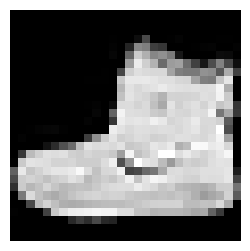

In [2]:
ds = torchvision.datasets.FashionMNIST(
    root="../data", train=True, download=True,
    transform=T.ToTensor(),
)
img, label = ds[0]
print("image:", img.shape, "label:", label, "(", ds.classes[label], ")")
show_image(img)

## 2. A blur kernel by hand

A box blur is a 3×3 kernel of `1/9`. Every output pixel = average of the 3×3
neighborhood in the input.

kernel shape (out_c, in_c, kH, kW): torch.Size([1, 1, 3, 3])
in: torch.Size([1, 1, 28, 28]) out: torch.Size([1, 1, 28, 28])


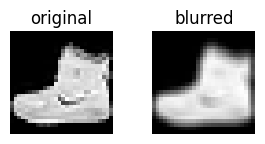

In [3]:
blur = torch.full((1, 1, 3, 3), 1/9)
print("kernel shape (out_c, in_c, kH, kW):", blur.shape)

x = img.unsqueeze(0)                     # (1, 1, 28, 28)
blurred = F.conv2d(x, blur, padding=1)
print("in:", x.shape, "out:", blurred.shape)

show_grid([img, blurred[0]], titles=["original", "blurred"], cols=2)

## 3. Edge detection — Sobel

Two kernels, one detects vertical edges, one horizontal. The magnitude of the
combined response highlights *all* edges.

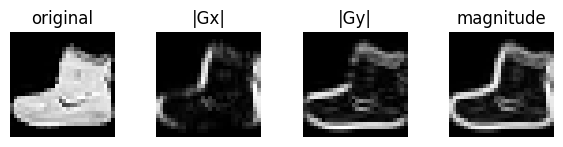

In [4]:
sobel_x = torch.tensor([[-1., 0., 1.],
                        [-2., 0., 2.],
                        [-1., 0., 1.]]).view(1, 1, 3, 3)
sobel_y = sobel_x.transpose(-1, -2)

gx = F.conv2d(x, sobel_x, padding=1)
gy = F.conv2d(x, sobel_y, padding=1)
mag = (gx**2 + gy**2).sqrt()

show_grid(
    [img, gx[0].abs(), gy[0].abs(), mag[0]],
    titles=["original", "|Gx|", "|Gy|", "magnitude"],
    cols=4,
)

## 4. The shape rule

For a kernel of size `k` with stride `s` and padding `p`,
the output spatial size is

`out = floor((in + 2p - k) / s) + 1`.

Memorize this. Half of all CNN debugging is verifying this equation.

In [5]:
def out_size(in_size, k, s=1, p=0):
    return (in_size + 2*p - k) // s + 1

for k, s, p in [(3, 1, 0), (3, 1, 1), (5, 2, 2), (7, 2, 3)]:
    print(f"k={k} s={s} p={p}  ->  28 -> {out_size(28, k, s, p)}")

k=3 s=1 p=0  ->  28 -> 26
k=3 s=1 p=1  ->  28 -> 28
k=5 s=2 p=2  ->  28 -> 14
k=7 s=2 p=3  ->  28 -> 14


## 5. Learned filters preview

Real CNNs start with *random* kernels and train them. Here we just glance at
what a randomly initialized 8-filter conv layer "sees" before any training —
mostly noise, but with interesting structure already.

feature maps: torch.Size([1, 8, 28, 28])


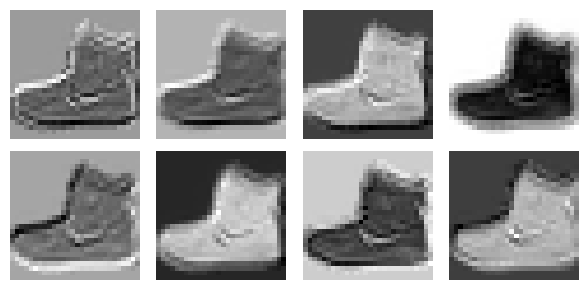

In [6]:
torch.manual_seed(0)
conv = torch.nn.Conv2d(1, 8, kernel_size=3, padding=1)
feat = conv(x)
print("feature maps:", feat.shape)
show_grid([feat[0, i].detach() for i in range(8)], cols=4)

## Recap

- A convolution slides a small kernel over the image, producing one number per location.
- Hand-built kernels can blur, sharpen, detect edges.
- CNNs learn these kernels from data — same operation, learned weights.
- The shape rule is non-negotiable: `(in + 2p - k) / s + 1`.

Next: **datasets and DataLoader** — feeding batches into a network without losing your sanity.